In [1]:
import numpy as np 
import matplotlib.pyplot as plt
%pip install -q tensorflow
try:
    import tensorflow as tf
except ModuleNotFoundError:
    %pip install -q tensorflow
    import tensorflow as tf

from tensorflow import keras 
from tensorflow.keras import layers



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
(X_train , y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [3]:
print("X_train : ", X_train.shape)
print("y_train : ", y_train.shape)
print("X_test : ", X_test.shape)
print("y_test : ", y_test.shape)

X_train :  (50000, 32, 32, 3)
y_train :  (50000, 1)
X_test :  (10000, 32, 32, 3)
y_test :  (10000, 1)


In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

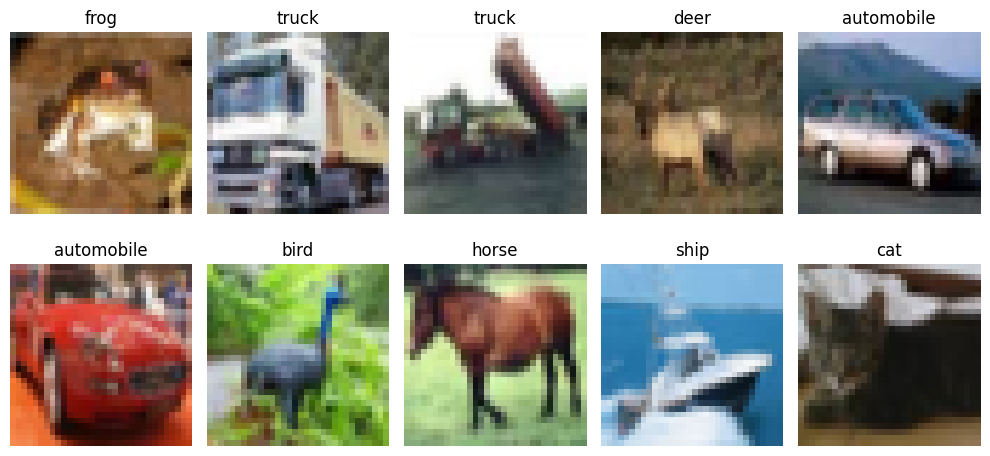

In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
print(X_train[0].shape)

(32, 32, 3)


In [8]:
class_names[2]

'bird'

In [9]:
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

Minimum : 0
Maximum : 255


In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [12]:
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())
print("Type :", X_train.dtype)

Minimum : 0.0
Maximum : 0.003921569
Type : float32


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [14]:
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

X_train : (45000, 32, 32, 3)
X_val   : (5000, 32, 32, 3)
X_test  : (10000, 32, 32, 3)
y_train : (45000, 1)
y_val   : (5000, 1)
y_test  : (10000, 1)


In [15]:
model = keras.Sequential([
    
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(
        128,
        activation="relu"
    ),
    
    layers.Dense(
        10,
        activation="softmax"
    )
])

c:\Users\ThinkPad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(
    X_train,y_train,epochs=10,batch_size=64, validation_data=(X_val,y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.1669 - loss: 2.2094 - val_accuracy: 0.2376 - val_loss: 2.0771
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2568 - loss: 2.0496 - val_accuracy: 0.2736 - val_loss: 2.0134
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2795 - loss: 1.9929 - val_accuracy: 0.2832 - val_loss: 1.9713
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2939 - loss: 1.9496 - val_accuracy: 0.3026 - val_loss: 1.9262
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3071 - loss: 1.9141 - val_accuracy: 0.3196 - val_loss: 1.8937
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3150 - loss: 1.8898 - val_accuracy: 0.3230 - val_loss: 1.8718
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3231 - loss: 1.8672 - val_accuracy: 0.3308 - val_loss: 1.8694
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3318 - loss: 1.8479 - val_ac

In [21]:
history = model.history

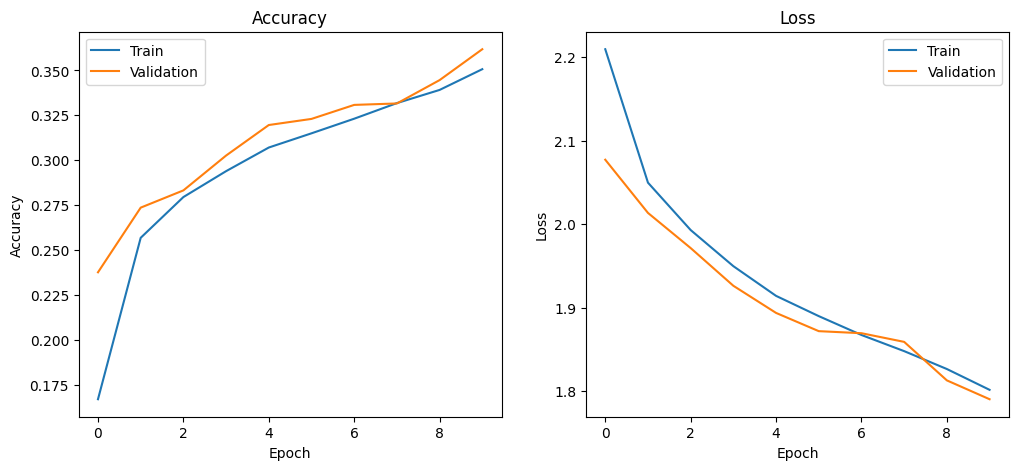

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
history = model.history
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
test_loss , test_accuracy = model.evaluate(X_test,y_test)
print("testloss:", test_loss)
print("test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3596 - loss: 1.7825
testloss: 1.7824926376342773
test accuracy: 0.3596000075340271


In [25]:
y_pred_proba = model.predict(X_test)

y_pred = np.argmax(y_pred_proba, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


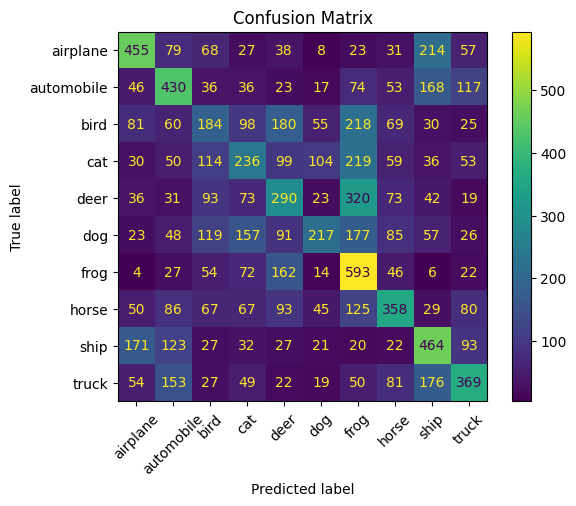

In [27]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.48      0.46      0.47      1000
  automobile       0.40      0.43      0.41      1000
        bird       0.23      0.18      0.21      1000
         cat       0.28      0.24      0.26      1000
        deer       0.28      0.29      0.29      1000
         dog       0.41      0.22      0.28      1000
        frog       0.33      0.59      0.42      1000
       horse       0.41      0.36      0.38      1000
        ship       0.38      0.46      0.42      1000
       truck       0.43      0.37      0.40      1000

    accuracy                           0.36     10000
   macro avg       0.36      0.36      0.35     10000
weighted avg       0.36      0.36      0.35     10000

